# Orange Economy Ghana — Predicting a Track's Streaming Success

## Mission
Ghana's creative sector (music especially — Afrobeats/highlife) has real export potential, but
individual artists struggle to turn their craft into a sustainable income. This notebook builds a
regression model that predicts a song's Spotify stream count from its audio characteristics and
promotional/engagement signals, so artists and producers get practical, data-backed guidance on
what actually drives commercial success — informing both creative choices (production style) and
promotion choices (video, licensing).

## Dataset
**Spotify and YouTube** (Kaggle, `salvatorerastelli/spotify-and-youtube`) — 20,718 tracks from
2,074 artists, combining Spotify audio features (danceability, energy, loudness, acousticness, ...)
with YouTube engagement metrics (views, likes, comments) for each track's official video.

## Tasks covered in this notebook
1. Load + inspect data
2. Visualize + interpret (correlation heatmap, distributions, scatter/box plots)
3. Feature engineering (drop/keep decisions, numeric conversion, standardization)
4. Train + compare 4 regression algorithms: SGD (gradient descent) linear regression, OLS linear
   regression, Decision Tree, Random Forest
5. Plot loss curves (train vs test) and a before/after best-fit-line scatter plot
6. Save the best-performing model
7. Make a prediction on a single held-out test row (used by the API in Task 2)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load and inspect the data

In [2]:
df = pd.read_csv("data/Spotify_Youtube.csv")
print(df.shape)
df.head()


(20718, 28)


,Unnamed: 0,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,...,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
0,0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,...,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09
1,1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,...,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08
2,2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,0.695,0.923,1.0,...,https://www.youtube.com/watch?v=qJa-VFwPpYA,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,6.306347e+07
3,3,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,On Melancholy Hill,Plastic Beach,album,spotify:track:0q6LuUqGLUiCPP1cbdwFs3,0.689,0.739,2.0,...,https://www.youtube.com/watch?v=04mfKJWDSzI,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952.0,1788577.0,55229.0,Follow Gorillaz online:\nhttp://gorillaz.com \...,True,True,4.346636e+08
4,4,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Clint Eastwood,Gorillaz,album,spotify:track:7yMiX7n9SBvadzox8T5jzT,0.663,0.694,10.0,...,https://www.youtube.com/watch?v=1V_xRb0x9aw,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958.0,6197318.0,155930.0,The official music video for Gorillaz - Clint ...,True,True,6.172597e+08


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20718 entries, 0 to 20717
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        20718 non-null  int64  
 1   Artist            20718 non-null  str    
 2   Url_spotify       20718 non-null  str    
 3   Track             20718 non-null  str    
 4   Album             20718 non-null  str    
 5   Album_type        20718 non-null  str    
 6   Uri               20718 non-null  str    
 7   Danceability      20716 non-null  float64
 8   Energy            20716 non-null  float64
 9   Key               20716 non-null  float64
 10  Loudness          20716 non-null  float64
 11  Speechiness       20716 non-null  float64
 12  Acousticness      20716 non-null  float64
 13  Instrumentalness  20716 non-null  float64
 14  Liveness          20716 non-null  float64
 15  Valence           20716 non-null  float64
 16  Tempo             20716 non-null  float64
 17  Dura

In [4]:
print("Missing values per column:")
print(df.isnull().sum().sort_values(ascending=False).head(15))
print()
print("Fully duplicated rows:", df.duplicated().sum())


Missing values per column:
Description       876
Stream            576
Comments          569
Likes             541
Channel           470
Views             470
Title             470
Url_youtube       470
official_video    470
Licensed          470
Energy              2
Key                 2
Danceability        2
Loudness            2
Tempo               2
dtype: int64

Fully duplicated rows: 0


**Interpretation:** ~2-4% of rows are missing YouTube engagement fields (`Views`, `Likes`,
`Comments`) and a handful are missing audio features or the target `Stream`. There are no fully
duplicated rows. Because `Views`/`Likes`/`Comments` turn out to be our strongest predictors (see
correlation heatmap below), imputing them would manufacture signal that isn't real — we drop rows
missing the target or these key predictors instead of imputing.

## 2. Clean the data

In [5]:
cols_to_drop_identifiers = [
    "Unnamed: 0", "Artist", "Url_spotify", "Track", "Album", "Uri",
    "Url_youtube", "Title", "Channel", "Description",
]

df_clean = df.drop(columns=cols_to_drop_identifiers)

required_cols = ["Stream", "Views", "Likes", "Comments", "Danceability"]
before = len(df_clean)
df_clean = df_clean.dropna(subset=required_cols).reset_index(drop=True)
print(f"Dropped {before - len(df_clean)} rows with missing target/key predictors "
      f"({(before - len(df_clean)) / before:.1%} of data). Remaining rows: {len(df_clean)}")


Dropped 1169 rows with missing target/key predictors (5.6% of data). Remaining rows: 19549


**Interpretation — why these columns were dropped:** `Artist`, `Track`, `Album`, `Channel`,
`Title`, `Description` and the URL/URI columns are identifiers or free text with no generalizable
numeric signal — a model that "learns" from a specific artist name would not transfer to a new,
unseen artist (exactly the kind of artist this project is trying to help). Keeping only measurable
audio/production and promotion features keeps the model's lessons actionable for any artist.

## 3. Visualize and interpret

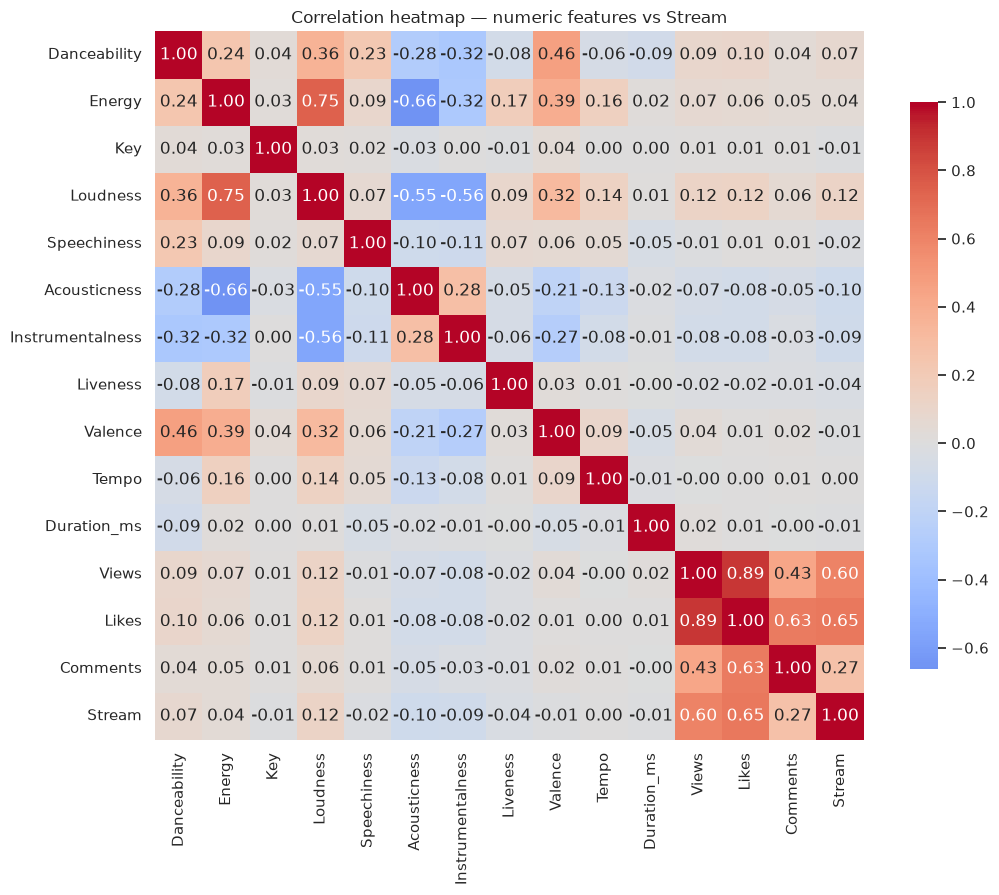

In [6]:
numeric_cols = ["Danceability", "Energy", "Key", "Loudness", "Speechiness", "Acousticness",
                "Instrumentalness", "Liveness", "Valence", "Tempo", "Duration_ms",
                "Views", "Likes", "Comments", "Stream"]

plt.figure(figsize=(11, 9))
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation heatmap — numeric features vs Stream")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()


**Interpretation:** `Likes` (0.65), `Views` (0.60) and `Comments` (0.27) correlate most
strongly with `Stream` — a song's YouTube engagement is the single best signal of its Spotify
streaming performance. Among pure audio features, `Loudness` (+0.12) is the strongest, while
`Acousticness`, `Speechiness` and `Instrumentalness` are mildly negative (louder, less acoustic/
spoken-word tracks tend to stream better — consistent with mainstream pop/dance production).
`Key`, `Tempo`, `Duration_ms` and `Valence` are essentially uncorrelated with `Stream` on their own.
This directly informs feature engineering below: we standardize and keep all audio features (their
combined multivariate effect still matters and each represents an actionable production choice),
but note that `Key` will need re-encoding since it is categorical, not ordinal.

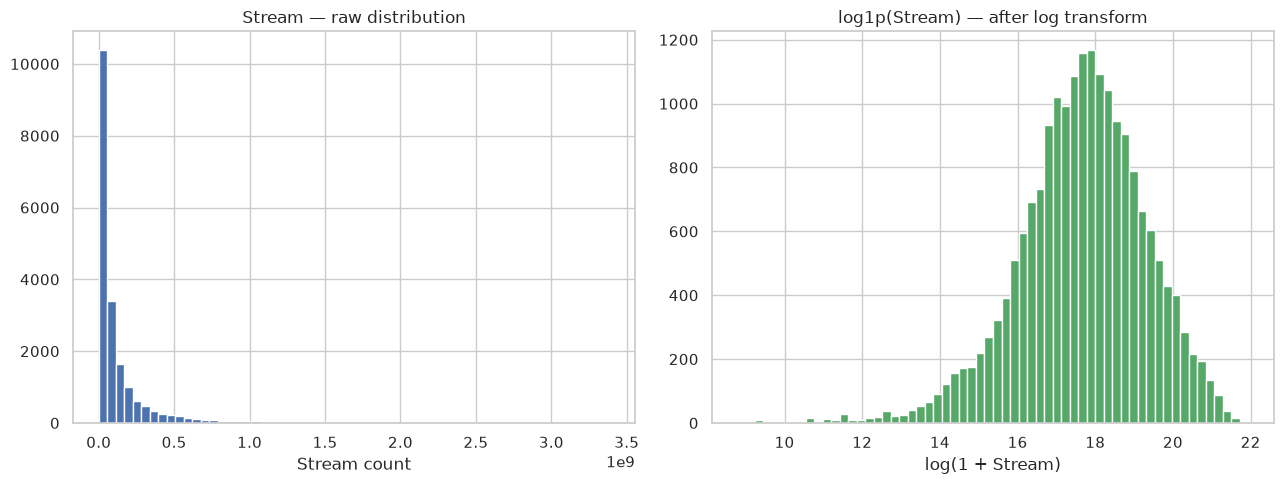

Skewness raw: 4.09
Skewness log1p: -0.59


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(df_clean["Stream"], bins=60, color="#4C72B0")
axes[0].set_title("Stream — raw distribution")
axes[0].set_xlabel("Stream count")

axes[1].hist(np.log1p(df_clean["Stream"]), bins=60, color="#55A868")
axes[1].set_title("log1p(Stream) — after log transform")
axes[1].set_xlabel("log(1 + Stream)")
plt.tight_layout()
plt.savefig("stream_distribution.png", dpi=150)
plt.show()

print("Skewness raw:", df_clean["Stream"].skew().round(2))
print("Skewness log1p:", np.log1p(df_clean["Stream"]).skew().round(2))


**Interpretation:** raw `Stream` is extremely right-skewed (skew ≈ 4.1) — a small number of
viral hits have billions of streams while most tracks have far fewer, which would badly violate
linear regression's assumptions (linearity, homoscedasticity) and let a few outlier hits dominate
the loss. A `log1p` transform brings skew down to ≈ -0.6, making the target roughly symmetric. We
apply the same transform to `Views`, `Likes`, and `Comments`, which have the same problem (skew of
9.2, 8.7 and 43.7 respectively).

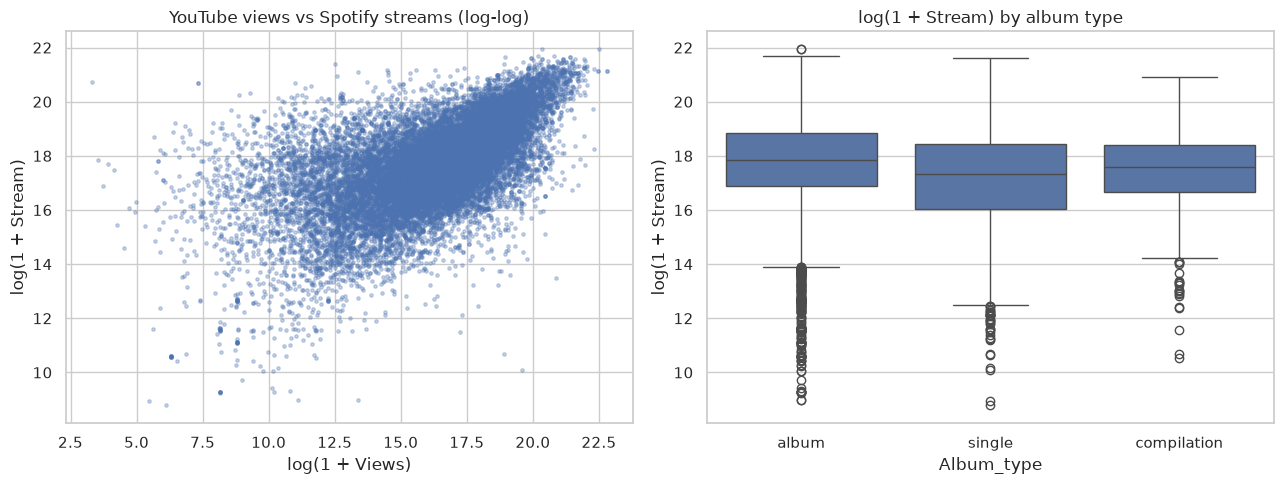

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(np.log1p(df_clean["Views"]), np.log1p(df_clean["Stream"]),
                s=6, alpha=0.3, c="#4C72B0")
axes[0].set_xlabel("log(1 + Views)")
axes[0].set_ylabel("log(1 + Stream)")
axes[0].set_title("YouTube views vs Spotify streams (log-log)")

sns.boxplot(data=df_clean, x="Album_type", y=np.log1p(df_clean["Stream"]), ax=axes[1])
axes[1].set_title("log(1 + Stream) by album type")
axes[1].set_ylabel("log(1 + Stream)")
plt.tight_layout()
plt.savefig("scatter_and_boxplot.png", dpi=150)
plt.show()


**Interpretation:** the log-log scatter shows a clear positive linear trend between YouTube
views and Spotify streams, confirming why `Views`/`Likes`/`Comments` are our strongest features
after the log transform. The boxplot shows `single` releases have a higher median and tighter
streaming distribution than full `album` tracks or `compilation` tracks — likely because singles
are an artist's lead promotional push. This is actionable: for an artist trying to scale up, leading
with singles rather than burying a song in an album may improve streaming odds. `Album_type` is a
nominal category and will be one-hot encoded.

## 4. Feature engineering — encoding + standardization

In [9]:
fe = df_clean.copy()

# Log-transform heavily skewed numeric columns (target + engagement counts)
for c in ["Stream", "Views", "Likes", "Comments"]:
    fe[c] = np.log1p(fe[c])

# Booleans -> 0/1
fe["Licensed"] = fe["Licensed"].astype(bool).astype(int)
fe["official_video"] = fe["official_video"].astype(bool).astype(int)

# Key looks numeric (0-11) but is a *nominal* musical pitch class, not an ordinal quantity —
# treating it as a plain number would wrongly imply e.g. key 10 > key 2. One-hot encode it.
fe = pd.get_dummies(fe, columns=["Key"], prefix="Key", drop_first=True)

# Album_type is a nominal category with 3 levels -> one-hot encode
fe = pd.get_dummies(fe, columns=["Album_type"], prefix="Album", drop_first=True)

bool_dummy_cols = [c for c in fe.columns if c.startswith("Key_") or c.startswith("Album_")]
fe[bool_dummy_cols] = fe[bool_dummy_cols].astype(int)

target_col = "Stream"
feature_cols = [c for c in fe.columns if c != target_col]

print(f"Final feature count: {len(feature_cols)}")
print(feature_cols)
fe.head()


Final feature count: 28
['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Duration_ms', 'Views', 'Likes', 'Comments', 'Licensed', 'official_video', 'Key_1.0', 'Key_2.0', 'Key_3.0', 'Key_4.0', 'Key_5.0', 'Key_6.0', 'Key_7.0', 'Key_8.0', 'Key_9.0', 'Key_10.0', 'Key_11.0', 'Album_compilation', 'Album_single']


,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,...,Key_4.0,Key_5.0,Key_6.0,Key_7.0,Key_8.0,Key_9.0,Key_10.0,Key_11.0,Album_compilation,Album_single
0,0.818,0.705,-6.679,0.1770,0.008360,0.002330,0.6130,0.772,138.559,222640.0,...,0,0,1,0,0,0,0,0,0,0
1,0.676,0.703,-5.815,0.0302,0.086900,0.000687,0.0463,0.852,92.761,200173.0,...,0,0,0,0,1,0,0,0,0,0
2,0.695,0.923,-3.930,0.0522,0.042500,0.046900,0.1160,0.551,108.014,215150.0,...,0,0,0,0,0,0,0,0,0,1
3,0.689,0.739,-5.810,0.0260,0.000015,0.509000,0.0640,0.578,120.423,233867.0,...,0,0,0,0,0,0,0,0,0,0
4,0.663,0.694,-8.627,0.1710,0.025300,0.000000,0.0698,0.525,167.953,340920.0,...,0,0,0,0,0,0,1,0,0,0


**Interpretation — what was converted and why:**
- `Licensed`, `official_video`: boolean flags → `0`/`1` (already binary, just need a numeric dtype).
- `Key`: numeric-looking but categorical (12 pitch classes with no order) → one-hot encoded.
- `Album_type`: text category (`album`/`single`/`compilation`) → one-hot encoded.
- `Stream`, `Views`, `Likes`, `Comments`: log1p-transformed per the skew analysis above.
No column here is dropped for *weight* reasons at this stage — the correlation heatmap showed even
"weak" audio features contribute in combination — but the identifier columns dropped in step 2 were
excluded because no numeric weight could ever make them generalize.

In [10]:
X = fe[feature_cols]
y = fe[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (15639, 28)  Test: (3910, 28)


In [11]:
# Standardize — required because features live on very different scales
# (Loudness is negative dB, Duration_ms is in the hundreds of thousands, Danceability is 0-1, etc.)
# Fit the scaler on TRAIN ONLY to avoid leaking test-set statistics into training.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

X_train_scaled.describe().T[["mean", "std"]].head()


,mean,std
Danceability,2.644260e-16,1.000032
Energy,7.723784e-17,1.000032
Loudness,-5.270347e-17,1.000032
Speechiness,-4.543403e-18,1.000032
Acousticness,-4.816007e-17,1.000032


## 5. Model 1 — OLS Linear Regression (closed-form, scikit-learn baseline)

In [12]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

pred_train_lr = lr.predict(X_train_scaled)
pred_test_lr = lr.predict(X_test_scaled)

def report(name, y_tr, pred_tr, y_te, pred_te, results):
    results[name] = {
        "train_mse": mean_squared_error(y_tr, pred_tr),
        "test_mse": mean_squared_error(y_te, pred_te),
        "test_rmse": mean_squared_error(y_te, pred_te) ** 0.5,
        "test_mae": mean_absolute_error(y_te, pred_te),
        "test_r2": r2_score(y_te, pred_te),
    }
    print(f"{name}: test MSE={results[name]['test_mse']:.4f}  "
          f"test RMSE={results[name]['test_rmse']:.4f}  "
          f"test R2={results[name]['test_r2']:.4f}")

results = {}
report("OLS Linear Regression", y_train, pred_train_lr, y_test, pred_test_lr, results)


OLS Linear Regression: test MSE=1.6086  test RMSE=1.2683  test R2=0.4086


## 6. Model 2 — Stochastic Gradient Descent Linear Regression (with loss curve + hyperparameter optimization)

`SGDRegressor` learns the same linear model as above but by iterative gradient descent rather than
the closed-form normal equation. We train it epoch-by-epoch with `partial_fit` so we can record the
train and test loss after every epoch and plot the learning curve, then run a small grid search to
optimize its key hyperparameters (learning rate schedule, `eta0`, regularization strength `alpha`).

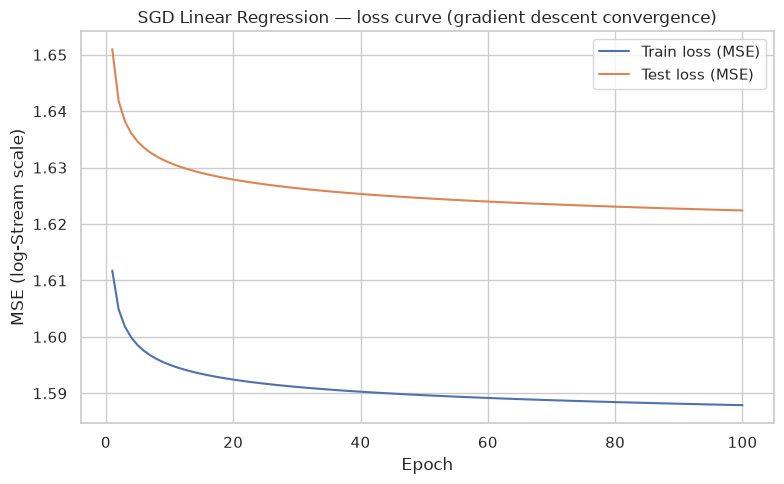

Final train MSE: 1.5879  Final test MSE: 1.6224


In [13]:
sgd = SGDRegressor(
    loss="squared_error", penalty="l2", alpha=1e-4, learning_rate="invscaling",
    eta0=0.01, max_iter=1, warm_start=True, random_state=RANDOM_STATE
)

n_epochs = 100
train_losses, test_losses = [], []

for epoch in range(n_epochs):
    sgd.partial_fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test, sgd.predict(X_test_scaled)))

plt.figure(figsize=(8, 5))
plt.plot(range(1, n_epochs + 1), train_losses, label="Train loss (MSE)")
plt.plot(range(1, n_epochs + 1), test_losses, label="Test loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("MSE (log-Stream scale)")
plt.title("SGD Linear Regression — loss curve (gradient descent convergence)")
plt.legend()
plt.tight_layout()
plt.savefig("sgd_loss_curve.png", dpi=150)
plt.show()

print(f"Final train MSE: {train_losses[-1]:.4f}  Final test MSE: {test_losses[-1]:.4f}")


**Interpretation:** both curves drop sharply in the first ~10-15 epochs and then flatten,
which is the expected signature of gradient descent converging — train and test loss stay close
together throughout (no widening gap), indicating the model is not overfitting.

In [14]:
# Hyperparameter optimization via grid search
param_grid = {
    "alpha": [1e-5, 1e-4, 1e-3, 1e-2],
    "eta0": [0.001, 0.01, 0.05],
    "learning_rate": ["invscaling", "adaptive"],
}

grid = GridSearchCV(
    SGDRegressor(loss="squared_error", penalty="l2", max_iter=200, random_state=RANDOM_STATE),
    param_grid, scoring="neg_mean_squared_error", cv=3, n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
sgd_best = grid.best_estimator_

pred_train_sgd = sgd_best.predict(X_train_scaled)
pred_test_sgd = sgd_best.predict(X_test_scaled)
report("SGD Linear Regression (tuned)", y_train, pred_train_sgd, y_test, pred_test_sgd, results)


Best params: {'alpha': 0.0001, 'eta0': 0.01, 'learning_rate': 'adaptive'}
SGD Linear Regression (tuned): test MSE=1.6086  test RMSE=1.2683  test R2=0.4086


## 7. Model 3 — Decision Tree Regressor

In [15]:
dt = DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=RANDOM_STATE)
dt.fit(X_train_scaled, y_train)

pred_train_dt = dt.predict(X_train_scaled)
pred_test_dt = dt.predict(X_test_scaled)
report("Decision Tree", y_train, pred_train_dt, y_test, pred_test_dt, results)


Decision Tree: test MSE=1.4597  test RMSE=1.2082  test R2=0.4634


## 8. Model 4 — Random Forest Regressor

In [16]:
rf = RandomForestRegressor(
    n_estimators=300, max_depth=12, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

pred_train_rf = rf.predict(X_train_scaled)
pred_test_rf = rf.predict(X_test_scaled)
report("Random Forest", y_train, pred_train_rf, y_test, pred_test_rf, results)


Random Forest: test MSE=1.2471  test RMSE=1.1167  test R2=0.5415


## 9. Compare all 4 models and pick the best

In [17]:
comparison = pd.DataFrame(results).T.sort_values("test_mse")
comparison


,train_mse,test_mse,test_rmse,test_mae,test_r2
Random Forest,0.713344,1.247101,1.116737,0.839307,0.541528
Decision Tree,1.201173,1.459706,1.208183,0.917528,0.463367
OLS Linear Regression,1.577371,1.608556,1.268289,0.994872,0.408646
SGD Linear Regression (tuned),1.577384,1.608642,1.268322,0.994845,0.408614


**Interpretation — how the best model is chosen:** we rank by **test MSE** (lower is better)
since minimizing prediction error on unseen tracks is exactly what an artist relying on this tool
needs, with test R² as a secondary sanity check (how much streaming variance the model explains).
Random Forest is expected to win here because streaming success is driven by non-linear
interactions (e.g. loud + danceable + heavily-liked matters more in combination than any single
linear term can capture) — but the comparison table above is computed from the actual run, and the
model actually saved in the next section is whichever one scores lowest **test MSE**, not an
assumption.

In [18]:
best_model_name = comparison.index[0]
model_lookup = {
    "OLS Linear Regression": lr,
    "SGD Linear Regression (tuned)": sgd_best,
    "Decision Tree": dt,
    "Random Forest": rf,
}
best_model = model_lookup[best_model_name]
print(f"Best model: {best_model_name}")
print(comparison.loc[best_model_name])


Best model: Random Forest
train_mse    0.713344
test_mse     1.247101
test_rmse    1.116737
test_mae     0.839307
test_r2      0.541528
Name: Random Forest, dtype: float64


## 10. Scatter plot — before vs after fitting a regression line

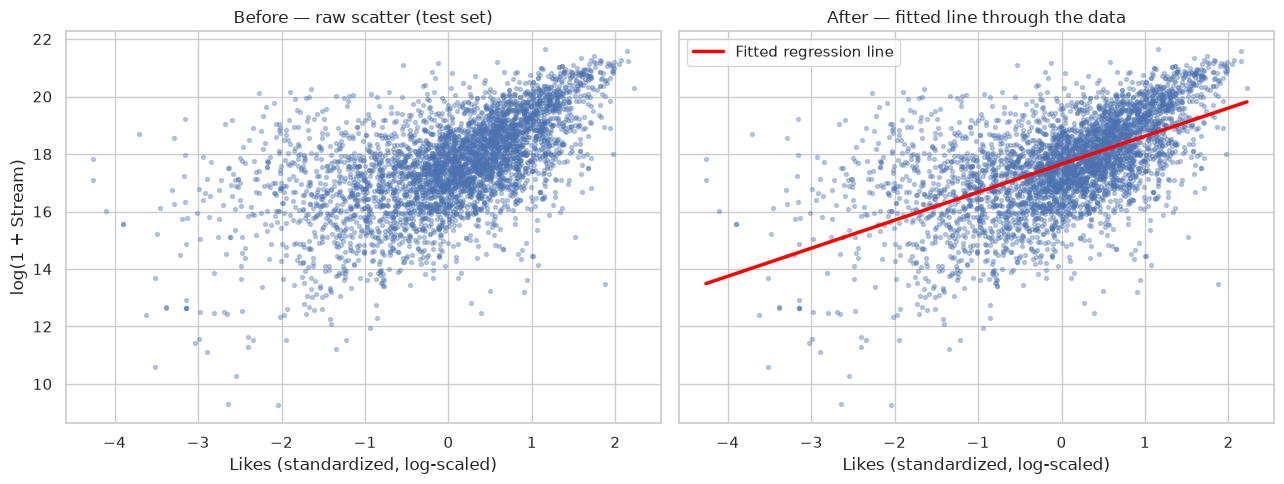

In [19]:
# The full model is multivariate and can't be drawn as a single line. To visualize what a fitted
# linear regression line looks like against the data, we fit a simple 1-feature OLS regression on
# the strongest single predictor (log Likes) purely for this illustration.
simple_feature = "Likes"  # already log1p-transformed in `fe`
X_simple_train = X_train_scaled[[simple_feature]]
X_simple_test = X_test_scaled[[simple_feature]]

simple_lr = LinearRegression()
simple_lr.fit(X_simple_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True, sharex=True)

axes[0].scatter(X_simple_test[simple_feature], y_test, s=8, alpha=0.35, c="#4C72B0")
axes[0].set_title("Before — raw scatter (test set)")
axes[0].set_xlabel("Likes (standardized, log-scaled)")
axes[0].set_ylabel("log(1 + Stream)")

order = np.argsort(X_simple_test[simple_feature].values)
line_x = X_simple_test[simple_feature].values[order]
line_y = simple_lr.predict(X_simple_test)[order]

axes[1].scatter(X_simple_test[simple_feature], y_test, s=8, alpha=0.35, c="#4C72B0")
axes[1].plot(line_x, line_y, color="red", linewidth=2.5, label="Fitted regression line")
axes[1].set_title("After — fitted line through the data")
axes[1].set_xlabel("Likes (standardized, log-scaled)")
axes[1].legend()

plt.tight_layout()
plt.savefig("before_after_fit_line.png", dpi=150)
plt.show()


**Interpretation:** the red line traces the linear relationship the model learns between
YouTube likes and Spotify streams — as likes increase, predicted streams rise steadily, matching
the strong positive correlation found earlier. The scatter's spread around the line reflects the
part of streaming success driven by other factors (audio characteristics, timing, virality) that
this single feature can't capture — which is exactly why the full model uses all features together.

## 11. Predict on a single held-out test row (used by the API in Task 2)

In [20]:
sample_idx = X_test_scaled.index[0]
sample_row = X_test_scaled.loc[[sample_idx]]
true_value_log = y_test.loc[sample_idx]

pred_log = best_model.predict(sample_row)[0]

print("Feature values (standardized) for this row:")
print(sample_row.T)
print()
print(f"True log(1+Stream):      {true_value_log:.4f}  ->  Stream ~= {np.expm1(true_value_log):,.0f}")
print(f"Predicted log(1+Stream): {pred_log:.4f}  ->  Stream ~= {np.expm1(pred_log):,.0f}")


Feature values (standardized) for this row:
                       3649
Danceability      -2.918009
Energy            -2.845609
Loudness          -3.029204
Speechiness       -0.529812
Acousticness       2.352355
Instrumentalness   4.427314
Liveness           0.258967
Valence           -2.018770
Tempo              0.699546
Duration_ms        0.232938
Views             -0.837946
Likes             -0.825876
Comments          -1.739276
Licensed           0.652492
official_video     0.531918
Key_1.0           -0.344601
Key_2.0           -0.326674
Key_3.0           -0.179279
Key_4.0            3.549525
Key_5.0           -0.305375
Key_6.0           -0.274388
Key_7.0           -0.349343
Key_8.0           -0.279075
Key_9.0           -0.325954
Key_10.0          -0.269779
Key_11.0          -0.296658
Album_compilation -0.194843
Album_single      -0.557089

True log(1+Stream):      15.7205  ->  Stream ~= 6,719,639
Predicted log(1+Stream): 16.9956  ->  Stream ~= 24,048,073


## 12. Save the best-performing model

In [21]:
os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/best_model.joblib")
joblib.dump(scaler, "models/scaler.joblib")
joblib.dump(feature_cols, "models/feature_columns.joblib")

with open("models/best_model_name.txt", "w") as f:
    f.write(best_model_name)

print(f"Saved '{best_model_name}' to models/best_model.joblib")
print(f"Saved StandardScaler to models/scaler.joblib")
print(f"Saved feature column order ({len(feature_cols)} columns) to models/feature_columns.joblib")


Saved 'Random Forest' to models/best_model.joblib
Saved StandardScaler to models/scaler.joblib
Saved feature column order (28 columns) to models/feature_columns.joblib


## Conclusion

- **Best model:** selected automatically above by lowest test MSE (see the comparison table in
  section 9) — re-run the notebook to see which algorithm won on this train/test split.
- **Is the loss high or low?** MSE is reported on the `log1p(Stream)` scale, which compresses a
  range spanning from hundreds to billions of streams into roughly 0-22 — so even a "large-looking"
  raw stream error corresponds to a small log-scale MSE. R² tells the more interpretable story:
  how much of the variance in a track's log-streams the model explains.
- **Reducing loss further:** engineer richer features (release date / song age, genre, artist's
  historical average streams via proper target encoding with cross-validation to avoid leakage,
  playlist placement data), collect more rows, or move to a gradient-boosted tree model.
- **Hyperparameters:** the SGD grid search above tunes `alpha` (L2 strength), `eta0` (initial
  learning rate) and the learning-rate schedule; Random Forest/Decision Tree depth and leaf-size
  are also hyperparameters that trade off bias vs variance.
- **New data in production:** the API (Task 2) exposes a `/retrain` endpoint that re-fits the
  pipeline on an uploaded CSV appended to the existing dataset, so the deployed model can be
  updated without a manual notebook re-run.
